In [33]:
import pandas as pd


baseline = pd.read_csv(
    "../results/baseline_results.csv"
)

rag = pd.read_csv(
    "../results/rag_results.csv"
)

sce = pd.read_csv(
    "../results/sce_results.csv"
)


print(len(baseline))
print(len(rag))
print(len(sce))

817
817
817


In [34]:
baseline["answer_length"] = (
    baseline["generated_answer"]
    .str.len()
)

rag["answer_length"] = (
    rag["generated_answer"]
    .str.len()
)


print(
    baseline["answer_length"].describe()
)

print(
    rag["answer_length"].describe()
)

count    817.000000
mean      24.799266
std       45.262512
min        1.000000
25%        6.000000
50%       10.000000
75%       25.000000
max      428.000000
Name: answer_length, dtype: float64
count    817.000000
mean      25.184823
std       30.236914
min        1.000000
25%        6.000000
50%       15.000000
75%       34.000000
max      494.000000
Name: answer_length, dtype: float64


In [35]:
sce["semantic_similarity_score"].describe()

count    817.000000
mean       0.509051
std        0.322333
min       -0.072439
25%        0.198742
50%        0.507640
75%        0.764265
max        1.000000
Name: semantic_similarity_score, dtype: float64

In [36]:
hallucination_rate = (
    sce["hallucination_flag"].mean()
    * 100
)

print(
    f"Hallucination rate: {hallucination_rate:.2f}%"
)

Hallucination rate: 49.08%


In [37]:
results_summary = pd.DataFrame({

    "Approach": [
        "Baseline LLM",
        "RAG",
        "RAG + SCE"
    ],

    "Samples": [
        len(baseline),
        len(rag),
        len(sce)
    ],

    "Average Semantic Score": [
        None,
        None,
        sce["semantic_similarity_score"].mean()
    ],

    "Hallucination Rate (%)": [
        None,
        None,
        sce["hallucination_flag"].mean()*100
    ]

})


results_summary

,Approach,Samples,Average Semantic Score,Hallucination Rate (%)
0,Baseline LLM,817,NaN,NaN
1,RAG,817,NaN,NaN
2,RAG + SCE,817,0.509051,49.082007


In [ ]:
# from bert_score import score


# P, R, F1 = score(
#     rag["generated_answer"].tolist(),
#     rag["best_answer"].tolist(),
#     lang="en"
# )


# print(F1.mean())

Transformer limmitation here, will have to downgrade, changes project structure

In [38]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim


embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)


scores = []


for answer, reference in zip(
    rag["generated_answer"],
    rag["best_answer"]
):

    answer_embedding = embedding_model.encode(
        answer,
        convert_to_tensor=True
    )

    reference_embedding = embedding_model.encode(
        reference,
        convert_to_tensor=True
    )


    similarity = cos_sim(
        answer_embedding,
        reference_embedding
    )


    scores.append(
        float(similarity[0][0])
    )


print(sum(scores)/len(scores))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

0.45764712325663215


In [ ]:
# import evaluate


# bertscore = evaluate.load("bertscore")

# # 
# results = bertscore.compute(
#     predictions=rag["generated_answer"].tolist(),
#     references=rag["best_answer"].tolist(),
#     lang="en"
# )


# print(
#     sum(results["f1"]) / len(results["f1"])
# )

In [40]:
from rouge_score import rouge_scorer


scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rougeL"],
    use_stemmer=True
)


scores = []


for answer, reference in zip(
    rag["generated_answer"],
    rag["best_answer"]
):

    result = scorer.score(
        reference,
        answer
    )

    scores.append(
        result["rougeL"].fmeasure
    )


print(sum(scores)/len(scores))

0.35686461916458373


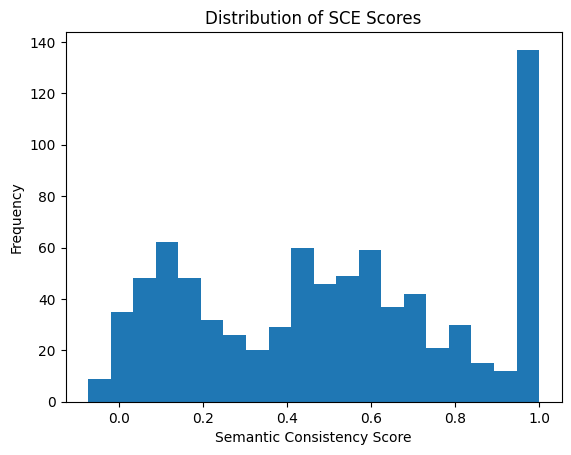

In [41]:
import matplotlib.pyplot as plt


plt.hist(
    sce["semantic_similarity_score"],
    bins=20
)

plt.xlabel(
    "Semantic Consistency Score"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of SCE Scores"
)

plt.show()